## Понижение размерности для задачи регрессии

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import umap

from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.feature_selection import RFE, VarianceThreshold, SelectKBest
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

### Чтение данных

In [2]:
data = pd.read_csv('../data/credit_card_fraud_filtered.csv')

y = data['fraud']
x = data.drop('fraud', axis=1)

In [3]:
x.head(10)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,high_price_anomaly
0,57.877857,0.311140,1.945940,1,1,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0
3,2.247564,5.600044,0.362663,1,1,0,1,0
4,44.190936,0.566486,2.222767,1,1,0,1,0
5,3.724019,0.956838,0.278465,1,0,0,1,0
6,4.848247,0.320735,1.273050,1,0,1,0,0
7,0.876632,2.503609,1.516999,0,0,0,0,0
8,8.839047,2.970512,2.361683,1,0,0,1,0
9,14.263530,0.158758,1.136102,1,1,0,1,0


In [4]:
y.head(5)

0    0
1    0
2    0
3    0
4    0
Name: fraud, dtype: int64

In [37]:
results = []

def test(x_test, y=y):
    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BaggingClassifier(
        n_estimators=15,
        max_samples=0.67,
        max_features=0.91,
        random_state=81,
        n_jobs=-1
    ))
])

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    y_pred = cross_val_predict(pipeline, x_test, y, cv=kf, n_jobs=-1)
    f1 = f1_score(y, y_pred)

    print(classification_report(y, y_pred))
    print(confusion_matrix(y, y_pred))
    print(f"Средняя f1-score: {round(f1, 4)}")
    
    return round(f1, 4)

### Обучение без понижения размерности

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BaggingClassifier(
        n_estimators=15,
        max_samples=0.67,
        max_features=0.91,
        random_state=81,
        n_jobs=-1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=81)

y_pred = cross_val_predict(pipeline, x, y, cv=kf, n_jobs=-1)
f1 = f1_score(y, y_pred)

print(classification_report(y, y_pred))
print(confusion_matrix(y, y_pred))
print(f"Средняя f1-score: {round(f1, 4)}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      1.00      1.00     56670

    accuracy                           1.00    884794
   macro avg       1.00      1.00      1.00    884794
weighted avg       1.00      1.00      1.00    884794

[[828124      0]
 [    44  56626]]
Средняя f1-score: 0.9996


### Отбор признаков с высокой дисперсией (VarianceThreshold)

In [7]:
x.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,high_price_anomaly
count,884794.000000,884794.000000,884794.000000,884794.000000,884794.000000,884794.000000,884794.000000,884794.000000
mean,20.604745,3.142046,1.576615,0.897424,0.350425,0.100582,0.650406,0.053337
std,27.726534,5.568078,1.626536,0.303405,0.477103,0.300774,0.476842,0.224704
min,0.561957,0.024717,0.104734,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.052523,0.313376,0.492448,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.965197,0.998443,0.997746,1.000000,0.000000,0.000000,1.000000,0.000000
75%,24.623581,3.172139,2.025238,1.000000,1.000000,0.000000,1.000000,0.000000
max,177.425262,40.086104,9.506560,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
variances = x.var().sort_values()
variances

high_price_anomaly                  0.050492
used_pin_number                     0.090465
repeat_retailer                     0.092055
online_order                        0.227378
used_chip                           0.227628
ratio_to_median_purchase_price      2.645620
distance_from_last_transaction     31.003493
distance_from_home                768.760678
dtype: float64

In [9]:
vt  = VarianceThreshold(0.2)
x_vt = vt.fit_transform(x)

x_vt = pd.DataFrame(x_vt, columns=vt.get_feature_names_out())
x_vt.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,used_chip,online_order
0,57.877857,0.311140,1.945940,1.0,0.0
1,10.829943,0.175592,1.294219,0.0,0.0
2,5.091079,0.805153,0.427715,0.0,1.0
3,2.247564,5.600044,0.362663,1.0,1.0
4,44.190936,0.566486,2.222767,1.0,1.0


In [10]:
f1_vt = test(x_test=x_vt)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    828124
           1       0.90      0.90      0.90     56670

    accuracy                           0.99    884794
   macro avg       0.95      0.94      0.95    884794
weighted avg       0.99      0.99      0.99    884794

[[822583   5541]
 [  5932  50738]]
Средняя f1-score: 0.8984


In [38]:
results.append({"Method": "VarianceThreshold", "f1": f1_vt})

### Одномерный отбор признаков (SelectKBest)

In [12]:
skb = SelectKBest(k=4)
x_skb = skb.fit_transform(x, y)

f1_skb = test(x_skb)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    828124
           1       0.88      0.79      0.83     56670

    accuracy                           0.98    884794
   macro avg       0.93      0.89      0.91    884794
weighted avg       0.98      0.98      0.98    884794

[[822065   6059]
 [ 12103  44567]]
Средняя f1-score: 0.8307


In [39]:
results.append({"Method": "SelectKBest", "f1": f1_skb})

In [14]:
x_skb = pd.DataFrame(x_skb, columns=skb.get_feature_names_out())
x_skb.head()

,distance_from_home,ratio_to_median_purchase_price,online_order,high_price_anomaly
0,57.877857,1.945940,0.0,0.0
1,10.829943,1.294219,0.0,0.0
2,5.091079,0.427715,1.0,0.0
3,2.247564,0.362663,1.0,0.0
4,44.190936,2.222767,1.0,0.0


### Рекурсивный отбор признаков (RFE)

In [15]:
tree = DecisionTreeClassifier().fit(x, y)

rfe = RFE(estimator=tree, n_features_to_select=4, step=1).fit(x, y)
x_rfe = pd.DataFrame(rfe.transform(x), columns=rfe.get_feature_names_out())
f1_rfe = test(x_rfe)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    828124
           1       0.97      0.81      0.88     56670

    accuracy                           0.99    884794
   macro avg       0.98      0.90      0.94    884794
weighted avg       0.99      0.99      0.99    884794

[[826849   1275]
 [ 10793  45877]]
Средняя f1-score: 0.8838


In [40]:
results.append({"Method": "RFE", "f1": f1_rfe})

In [17]:
x_rfe.head()

,distance_from_home,ratio_to_median_purchase_price,used_pin_number,online_order
0,57.877857,1.945940,0.0,0.0
1,10.829943,1.294219,0.0,0.0
2,5.091079,0.427715,0.0,1.0
3,2.247564,0.362663,0.0,1.0
4,44.190936,2.222767,0.0,1.0


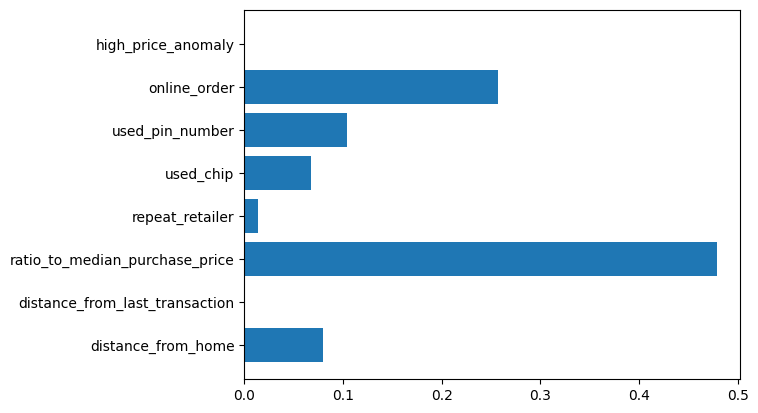

In [18]:
plt.barh(width=tree.feature_importances_, y=x.columns);

### Метод главных компонент (PCA)

In [19]:
pca_4 = PCA(n_components=4)
x_pca_4 = pd.DataFrame(pca_4.fit_transform(x, y), columns=pca_4.get_feature_names_out())

f1_pca_4 = test(x_pca_4)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      1.00      1.00     56670

    accuracy                           1.00    884794
   macro avg       1.00      1.00      1.00    884794
weighted avg       1.00      1.00      1.00    884794

[[827922    202]
 [   190  56480]]
Средняя f1-score: 0.9965


In [20]:
print(f"Сохранено информации {round(sum(pca_4.explained_variance_ratio_), 4)}")
x_pca_4.head()

Сохранено информации 0.9995


,pca0,pca1,pca2,pca3
0,37.273776,-2.823931,0.363779,0.813046
1,-9.773912,-2.968203,-0.287497,-0.141952
2,-15.512844,-2.339577,-1.149912,-0.438176
3,-18.357258,2.454743,-1.213546,0.517034
4,23.586817,-2.571279,0.638130,0.516498


In [41]:
results.append({"Method": "PCA", "f1": f1_pca_4})

In [22]:
pca_3 = PCA(n_components=3)
x_pca_3 = pca_3.fit_transform(x, y)

f1_pca_3 = test(x_pca_3)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97    828124
           1       0.63      0.44      0.52     56670

    accuracy                           0.95    884794
   macro avg       0.80      0.71      0.75    884794
weighted avg       0.94      0.95      0.94    884794

[[813213  14911]
 [ 31485  25185]]
Средняя f1-score: 0.5205


In [23]:
print(f"Сохранено информации {round(sum(pca_3.explained_variance_ratio_), 4)}")

Сохранено информации 0.9992


#### KernelPCA

In [24]:
k_pca_poly = KernelPCA(n_components=4, kernel='poly')

x_pca_poly = k_pca_poly.fit_transform(x.head(10_000))
x_pca_poly = pd.DataFrame(x_pca_poly, columns=k_pca_poly.get_feature_names_out())

f1_k_pca_poly = test(x_test=x_pca_poly, y=y.head(10_000))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      9366
           1       0.57      0.32      0.41       634

    accuracy                           0.94     10000
   macro avg       0.76      0.65      0.69     10000
weighted avg       0.93      0.94      0.93     10000

[[9213  153]
 [ 431  203]]
Средняя f1-score: 0.4101


In [25]:
k_pca_rbf = KernelPCA(n_components=4, kernel='rbf')

x_pca_rbf = k_pca_rbf.fit_transform(x.head(10_000))
x_pca_rbf = pd.DataFrame(x_pca_rbf, columns=k_pca_rbf.get_feature_names_out())

f1_k_pca_rbf = test(x_test=x_pca_rbf, y=y.head(10_000))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9366
           1       0.45      0.24      0.32       634

    accuracy                           0.93     10000
   macro avg       0.70      0.61      0.64     10000
weighted avg       0.92      0.93      0.92     10000

[[9173  193]
 [ 479  155]]
Средняя f1-score: 0.3157


In [26]:
k_pca_sigmoid = KernelPCA(n_components=4, kernel='sigmoid')

x_pca_sigmoid = k_pca_sigmoid.fit_transform(x.head(10_000))
x_pca_sigmoid = pd.DataFrame(x_pca_sigmoid, columns=k_pca_sigmoid.get_feature_names_out())

f1_k_pca_sigmoid = test(x_test=x_pca_sigmoid, y=y.head(10_000))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      9366
           1       0.81      0.32      0.45       634

    accuracy                           0.95     10000
   macro avg       0.88      0.66      0.71     10000
weighted avg       0.95      0.95      0.94     10000

[[9318   48]
 [ 434  200]]
Средняя f1-score: 0.4535


### Нелинейные методы выбора признаков

#### TSNE

In [27]:
tsne = TSNE(n_components=3)
x_tsne = tsne.fit_transform(x.head(10_000))
x_tsne = pd.DataFrame(x_tsne)

f1_tsne = test(x_test=x.head(10_000), y=y.head(10_000))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9366
           1       1.00      0.98      0.99       634

    accuracy                           1.00     10000
   macro avg       1.00      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000

[[9364    2]
 [  10  624]]
Средняя f1-score: 0.9905


In [42]:
results.append({"Method": "TSNE", "f1": f1_tsne})

In [29]:
x_tsne.head()

,0,1,2
0,20.254635,11.768467,11.066393
1,-0.071941,-19.284422,6.661139
2,-17.472929,-9.896862,-0.561576
3,-12.072950,3.952201,-5.795649
4,15.173079,19.154861,-3.841305


#### Isomap

In [30]:
isomap = Isomap(n_components=3)
x_isomap = isomap.fit_transform(x.head(10_000))
x_isomap = pd.DataFrame(x_isomap)


f1_isomap = test(x_test=x.head(10_000), y=y.head(10_000))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9366
           1       1.00      0.98      0.99       634

    accuracy                           1.00     10000
   macro avg       1.00      0.99      0.99     10000
weighted avg       1.00      1.00      1.00     10000

[[9364    2]
 [  10  624]]
Средняя f1-score: 0.9905


In [43]:
results.append({"Method": "Isomap", "f1" : f1_isomap})

In [32]:
x_tsne.head()

,0,1,2
0,20.254635,11.768467,11.066393
1,-0.071941,-19.284422,6.661139
2,-17.472929,-9.896862,-0.561576
3,-12.072950,3.952201,-5.795649
4,15.173079,19.154861,-3.841305


#### UMAP

In [33]:
reducer = umap.UMAP(n_components=4, n_jobs=-1)
x_umap_values = reducer.fit_transform(x.head(10_000))

x_umap = pd.DataFrame(x_umap_values, columns=[f'umap_{i}' for i in range(x_umap_values.shape[1])])

f1_umap = test(x_umap, y=y.head(10_000))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      9366
           1       0.61      0.41      0.49       634

    accuracy                           0.95     10000
   macro avg       0.78      0.70      0.73     10000
weighted avg       0.94      0.95      0.94     10000

[[9196  170]
 [ 372  262]]
Средняя f1-score: 0.4916


In [44]:
results.append({"Method": "UMAP", "f1": round(f1_umap, 4)})

In [35]:
x_umap.head()

,umap_0,umap_1,umap_2,umap_3
0,0.743447,-2.213051,8.449718,6.917217
1,10.346862,4.678341,4.285065,1.404429
2,10.861488,5.249726,9.911582,2.711011
3,12.059750,4.544879,7.709794,5.596487
4,2.785371,-3.179801,4.849884,8.172702


### Вывод

In [45]:
res = pd.DataFrame(results)
res

,Method,f1
0,VarianceThreshold,0.8984
1,SelectKBest,0.8307
2,RFE,0.8838
3,PCA,0.9965
4,TSNE,0.9905
5,Isomap,0.9905
6,UMAP,0.4916


Лучше всего подошел `SelectKBest`👍

Алгоритмы `KPCA`, `TSNE`, `Isomap` потребовали больше времени, чем ожидалось.